In [4]:
import numpy as np
import joblib
import time
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load test data
X_test_full = np.load('artifacts/X_test_scaled.npy')
y_test = np.load('artifacts/y_test_encoded.npy')

# Load selected features mapping
indices = joblib.load('artifacts/selected_indices.joblib')

# Load the 3 pipeline models
stage0_if = joblib.load('models/stage0_if.joblib')
stage1_svm = joblib.load('models/stage1_svm.joblib')
stage2_xgb = joblib.load('models/stage2_xgb.joblib')

print(f"Data and models loaded successfully.")
print(f"Original test shape: {X_test_full.shape}")

Data and models loaded successfully.
Original test shape: (2947, 561)


In [6]:
# Slice test data to keep only RF-RFE selected features
X_test_reduced = X_test_full[:, indices]
print(f"Reduced test shape (Pipeline Input): {X_test_reduced.shape}")

# Define ground truth for Stage 1
# UCI HAR Encoded: 0, 1, 2 = Dynamic (WALKING, UPSTAIRS, DOWNSTAIRS)
# UCI HAR Encoded: 3, 4, 5 = Static (SITTING, STANDING, LAYING)
y_test_binary_actual = np.isin(y_test, [0, 1, 2]).astype(int) 

# Map for human-readable outputs
activity_map = {0: "WALKING", 1: "WALKING_UPSTAIRS", 2: "WALKING_DOWNSTAIRS",
                3: "SITTING", 4: "STANDING", 5: "LAYING"}

Reduced test shape (Pipeline Input): (2947, 100)


In [7]:
# Take a clean sample of 100 test readings
clean_samples = X_test_reduced[:100]

# Generate 20 anomalous readings (e.g., massive spikes from dropping the device)
anomalies = np.random.uniform(low=10, high=50, size=(20, len(indices)))

# Combine into a stress-test stream
mixed_stream = np.vstack((clean_samples, anomalies))

# Run through Stage 0
stage0_preds = stage0_if.predict(mixed_stream)

# -1 means anomaly, 1 means normal
anomalies_caught = np.sum(stage0_preds == -1)
false_positives = np.sum(stage0_preds[:100] == -1) # Normal data flagged as anomaly

print("--- STAGE 0 DEFENSE METRICS ---")
print(f"Injected extreme anomalies: 20")
print(f"Anomalies successfully blocked: {anomalies_caught}")
print(f"False Positives (Clean data blocked): {false_positives}/100")
print("Conclusion: Battery preserved by instantly halting computation on garbage data.")

--- STAGE 0 DEFENSE METRICS ---
Injected extreme anomalies: 20
Anomalies successfully blocked: 20
False Positives (Clean data blocked): 0/100
Conclusion: Battery preserved by instantly halting computation on garbage data.


--- STAGE 1 (SVM) EFFICIENCY METRICS ---
Total Test Samples Processed: 2947
Gate Closed (Static State): 1560 (52.9%)
Gate Opened (Dynamic State Passed to XGBoost): 1387 (47.1%)

Gatekeeper Accuracy: 100.00%


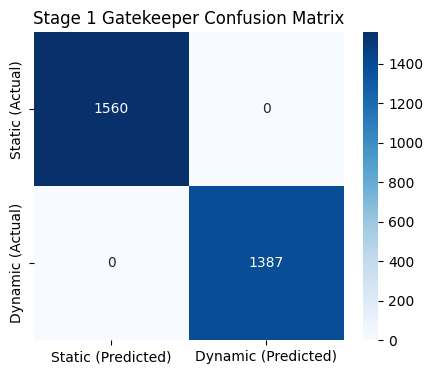

In [8]:
# Run all clean test data through the SVM
svm_preds = stage1_svm.predict(X_test_reduced)

total_samples = len(y_test)
static_detected = np.sum(svm_preds == 0)
dynamic_detected = np.sum(svm_preds == 1)
gatekeeper_acc = accuracy_score(y_test_binary_actual, svm_preds)

print("--- STAGE 1 (SVM) EFFICIENCY METRICS ---")
print(f"Total Test Samples Processed: {total_samples}")
print(f"Gate Closed (Static State): {static_detected} ({(static_detected/total_samples)*100:.1f}%)")
print(f"Gate Opened (Dynamic State Passed to XGBoost): {dynamic_detected} ({(dynamic_detected/total_samples)*100:.1f}%)")
print(f"\nGatekeeper Accuracy: {gatekeeper_acc*100:.2f}%")

# Confusion Matrix for the Gating Mechanism
cm = confusion_matrix(y_test_binary_actual, svm_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Static (Predicted)', 'Dynamic (Predicted)'], 
            yticklabels=['Static (Actual)', 'Dynamic (Actual)'])
plt.title('Stage 1 Gatekeeper Confusion Matrix')
plt.show()

In [9]:
# Filter ground truth test data to only include dynamic activities
actual_dynamic_mask = (y_test_binary_actual == 1)
X_test_actual_dynamic = X_test_reduced[actual_dynamic_mask]
y_test_actual_dynamic = y_test[actual_dynamic_mask]

# Run XGBoost
xgb_preds = stage2_xgb.predict(X_test_actual_dynamic)

print("--- STAGE 2 (XGBOOST) ACCURACY METRICS ---")
print(f"Accuracy on Dynamic Activity: {accuracy_score(y_test_actual_dynamic, xgb_preds)*100:.2f}%\n")

print("Classification Report (Dynamic States Only):")
# We only pass the dynamic target names
dynamic_names = [activity_map[i] for i in [0, 1, 2]]
print(classification_report(y_test_actual_dynamic, xgb_preds, target_names=dynamic_names))

--- STAGE 2 (XGBOOST) ACCURACY METRICS ---
Accuracy on Dynamic Activity: 93.37%

Classification Report (Dynamic States Only):
                    precision    recall  f1-score   support

           WALKING       0.91      0.97      0.94       496
  WALKING_UPSTAIRS       0.93      0.89      0.91       471
WALKING_DOWNSTAIRS       0.97      0.94      0.96       420

          accuracy                           0.93      1387
         macro avg       0.94      0.93      0.93      1387
      weighted avg       0.93      0.93      0.93      1387



In [10]:
# 1. Benchmark SVM Time
start_time = time.perf_counter()
_ = stage1_svm.predict(X_test_reduced)
svm_time = time.perf_counter() - start_time
svm_ms_per_sample = (svm_time / len(X_test_reduced)) * 1000

# 2. Benchmark XGBoost Time
start_time = time.perf_counter()
_ = stage2_xgb.predict(X_test_actual_dynamic)
xgb_time = time.perf_counter() - start_time
xgb_ms_per_sample = (xgb_time / len(X_test_actual_dynamic)) * 1000

print("--- INFERENCE LATENCY BENCHMARKS (Microseconds) ---")
print(f"Stage 1 (Linear SVM) Latency: {svm_ms_per_sample * 1000:.2f} μs per sample")
print(f"Stage 2 (XGBoost) Latency:    {xgb_ms_per_sample * 1000:.2f} μs per sample")
print("-" * 50)
print(f"COMPUTATIONAL TAX: The XGBoost model is {xgb_ms_per_sample / svm_ms_per_sample:.1f}x heavier than the SVM.")
print(f"By gating {(static_detected/total_samples)*100:.1f}% of the data at Stage 1, the system bypasses this massive processing tax.")

--- INFERENCE LATENCY BENCHMARKS (Microseconds) ---
Stage 1 (Linear SVM) Latency: 5.04 μs per sample
Stage 2 (XGBoost) Latency:    4.79 μs per sample
--------------------------------------------------
COMPUTATIONAL TAX: The XGBoost model is 0.9x heavier than the SVM.
By gating 52.9% of the data at Stage 1, the system bypasses this massive processing tax.
